In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('../../jupyter_notebooks/08-Linear-Regression-Models/Advertising.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [4]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


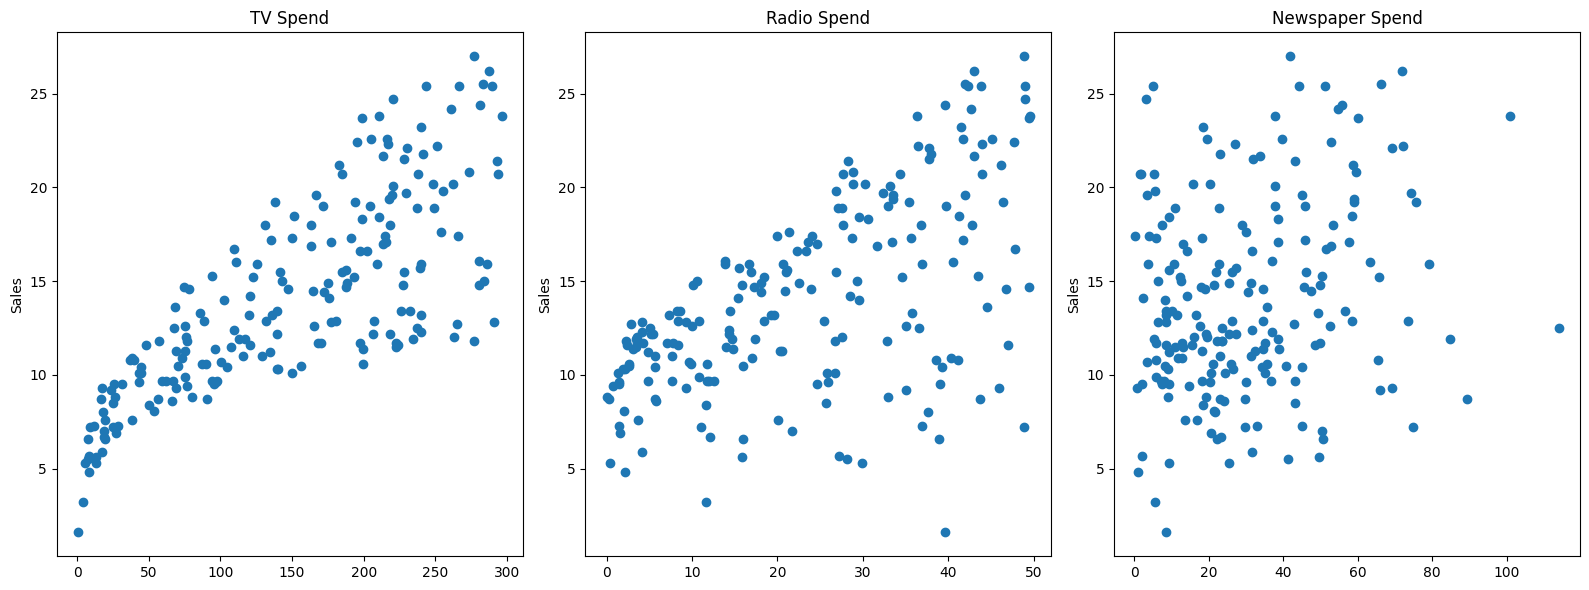

In [5]:
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(16,6))
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_ylabel("Sales")
axes[1].set_title("Radio Spend")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_ylabel("Sales")
axes[2].set_title("Newspaper Spend")

plt.tight_layout();

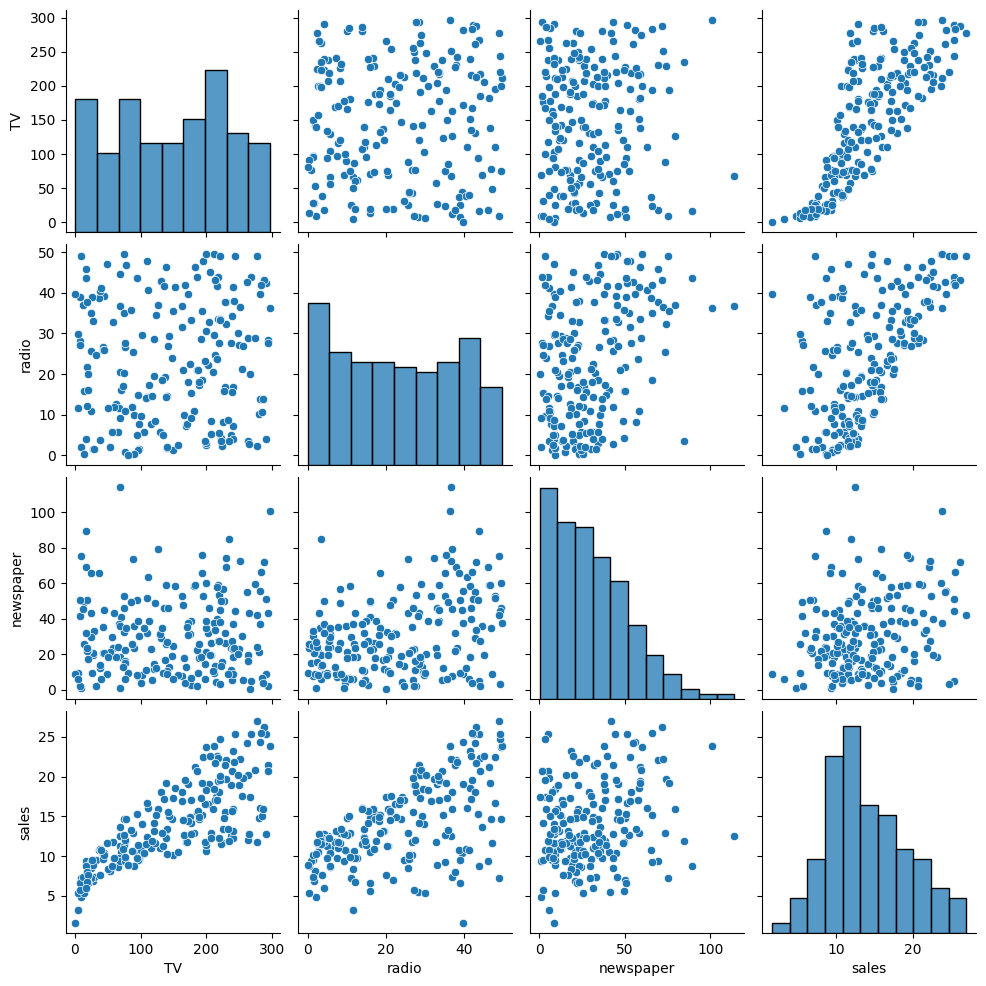

In [6]:
sns.pairplot(df)

In [7]:
X = df.drop('sales',axis=1)
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [8]:
y=df['sales']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [10]:
len(df)

200

In [11]:
len(X_train)

140

In [12]:
len(y_train)

140

In [13]:
len(X_test)

60

In [14]:
len(y_test)

60

In [15]:
#help (LinearRegression)
model = LinearRegression()

In [16]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
predictions=model.predict(X_test)

In [18]:
predictions

array([16.5653963 , 21.18822792, 21.55107058, 10.88923816, 22.20231988,
       13.35556872, 21.19692502,  7.35028523, 13.27547079, 15.12449511,
        9.01443026,  6.52542825, 14.30205991,  8.97026042,  9.45679576,
       12.00454351,  8.91549403, 16.15619251, 10.29582883, 18.72473553,
       19.76821818, 13.77469028, 12.49638908, 21.53501762,  7.60860741,
        5.6119801 , 20.91759483, 11.80627665,  9.08076637,  8.51412012,
       12.17604891,  9.9691939 , 21.73008956, 12.77770578, 18.1011362 ,
       20.07590796, 14.26202556, 20.93826535, 10.83938827,  4.38190607,
        9.51332406, 12.40486324, 10.17045434,  8.09081363, 13.16388427,
        5.2243552 ,  9.28893833, 14.09330719,  8.69024497, 11.66119763,
       15.71848432, 11.63156862, 13.35360735, 11.1531472 ,  6.33636845,
        9.76157954,  9.4195714 , 24.25516546,  7.69519137, 12.15317572])

In [19]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [20]:
df['sales'].mean()

np.float64(14.0225)

<Axes: xlabel='sales', ylabel='Count'>

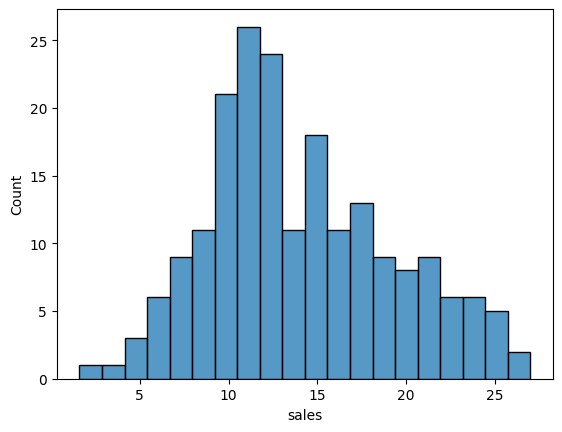

In [21]:
sns.histplot(data=df,x='sales',bins=20)

In [22]:
mean_absolute_error(y_test,predictions)

1.5116692224549086

In [23]:
# Root mean squared error
np.sqrt(mean_squared_error(y_test,predictions))

np.float64(1.9485372043446387)

# Residual Plots

You can calculate the distance between your model predictions and the actual values (that we know because we're using historical data) to get the residuals of the test set.
This residuals shall be random and responding to an approximately normal distribution. Once calculated, you can check if those hypothesis hold:
1. random
2. normally distributed

In [24]:
test_residuals = y_test-predictions
test_residuals

95     0.334604
15     1.211772
30    -0.151071
158   -3.589238
128    2.497680
115   -0.755569
69     1.103075
170    1.049715
174   -1.775471
45    -0.224495
66     0.485570
182    2.174572
165   -2.402060
78    -3.670260
186    0.843204
177   -0.304544
56    -3.415494
152    0.443807
82     1.004171
68     0.175264
124   -0.068218
16    -1.274690
148   -1.596389
93     0.664982
65     1.691393
60     2.488020
84     0.782405
67     1.593723
125    1.519234
132   -2.814120
9     -1.576049
18     1.330806
55     1.969910
75    -4.077706
150   -2.001136
104    0.624092
135   -2.662026
137   -0.138265
164    1.060612
76     2.518094
79     1.486676
197    0.395137
38    -0.070454
24     1.609186
122   -1.563884
195    2.375645
29     1.211062
19     0.506693
143    1.709755
86     0.338802
114   -1.118484
173    0.068431
5     -6.153607
126   -4.553147
117    3.063632
73     1.238420
140    1.480429
98     1.144835
172   -0.095191
96    -0.453176
Name: sales, dtype: float64

<Axes: xlabel='sales', ylabel='sales'>

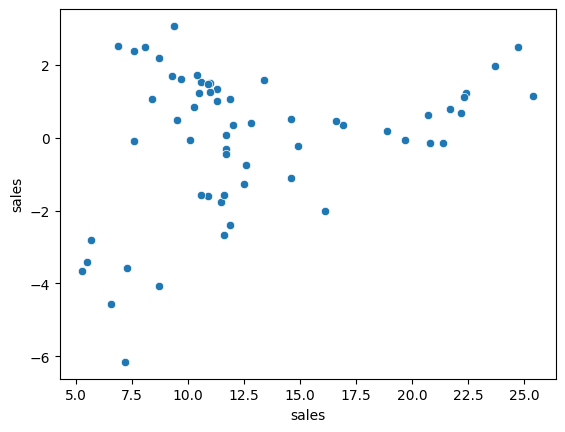

In [25]:
#plot residuals to check that there is no clear pattern. It should look random and have an even distribution around 0.
# If the residuals show a pattern, are close to a curve or a paravolic, or if they are not distributed close to 0, then Linear Regression is not a good choice.
sns.scatterplot(x=y_test,y=test_residuals)

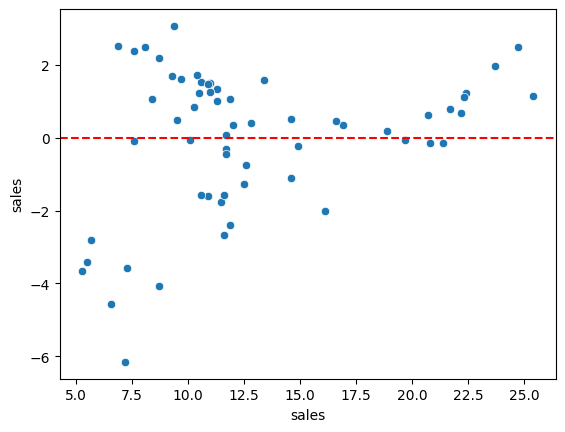

In [26]:
sns.scatterplot(x=y_test,y=test_residuals)
plt.axhline(y=0,color='r',ls='--')

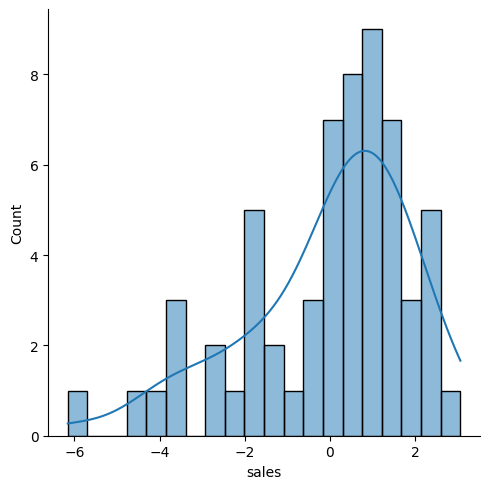

In [27]:
sns.displot(test_residuals,bins=20,kde=True)

In [28]:
import scipy as sp

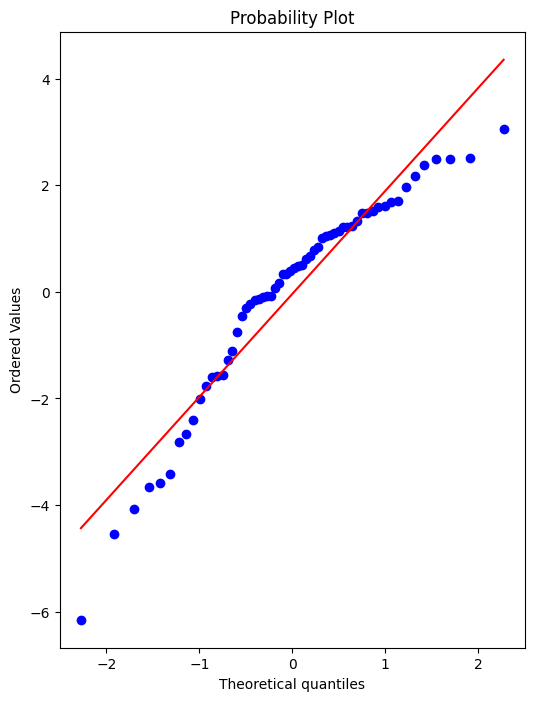

In [29]:
# plot residuals against a normal distribution to see if it is acceptable or we should get suspicious about Linear Regression
fig,ax=plt.subplots(figsize=(6,8),dpi=100)
_=sp.stats.probplot(test_residuals,plot=ax)

# Deployment

In [30]:
# Create a new instance of exactly the same model and parameters
final_model = LinearRegression()

In [31]:
# Feed the whole set of data to the model, since you have already checked that you are happy with the result, training it with more data is better.
final_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
final_coefs=final_model.coef_
final_coefs

array([ 0.04576465,  0.18853002, -0.00103749])

In [33]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [34]:
tv_spend = final_coefs[0]
radio_spend = final_coefs[1]
newspaper_spend = final_coefs[2]

## coeficient interpretation
As you can see, the coeficient for newspaper ads is close to zero, indicating that whatever amount of money you throw at newspapers has no or very little influence in the sales of this product.

In [35]:
# Let's validate predicting the whole X
y_hat = final_model.predict(X)

Text(0.5, 1.0, 'newspaper Spend')

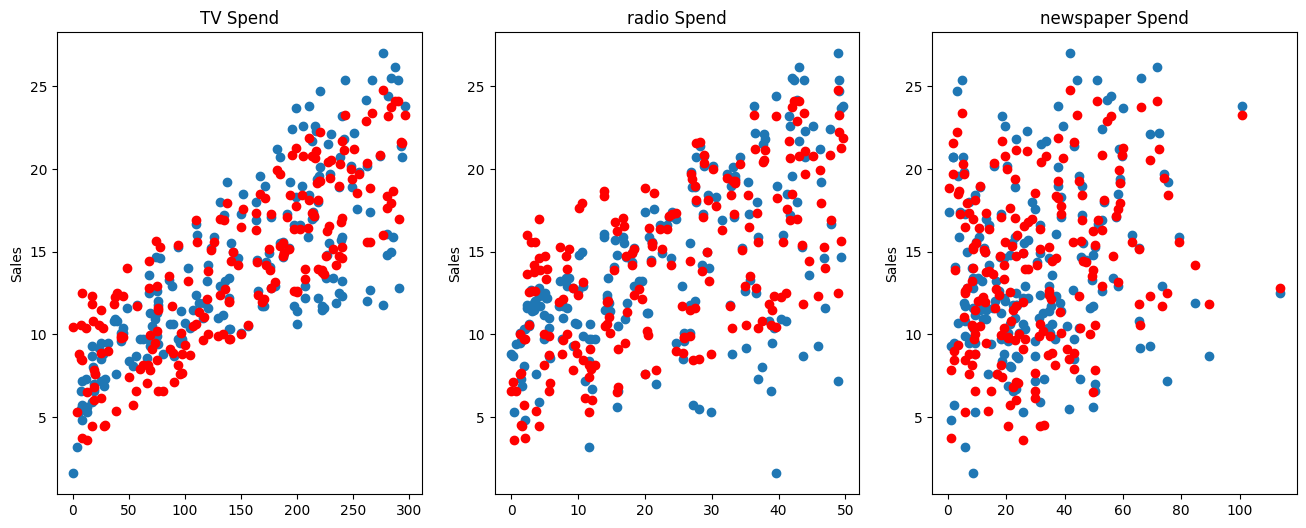

In [36]:
#plot the results
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))
axes[0].plot(df['TV'],df['sales'],'o')
axes[0].plot(df['TV'],y_hat,'o',color='red')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV Spend')

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].plot(df['radio'],y_hat,'o',color='red')
axes[1].set_ylabel('Sales')
axes[1].set_title('radio Spend')

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].plot(df['newspaper'],y_hat,'o',color='red')
axes[2].set_ylabel('Sales')
axes[2].set_title('newspaper Spend')

Pretty accurate.

## Model persistance
In order to be able to use it again/elsewere, you need to save/persist the model.

In [37]:
from joblib import dump,load

In [38]:
dump(final_model,'final_sales_model.joblib')

['final_sales_model.joblib']

# Now you can load the final_sales_model, which is an already-trained model, and run it anywhere. Here, for example

In [39]:
loaded_model = load('final_sales_model.joblib')

In [40]:
loaded_model.coef_

array([ 0.04576465,  0.18853002, -0.00103749])

Same coefficients as before.

In [41]:
# let's predict a new advertising campaign
#    first, let's see how our input data look like
X.shape

(200, 3)

In [42]:
# 149 TV, 22 Radio, 12 Newspaper; how many sales are to be expected of this campaign?
campaign = [[149,22,12]]

In [43]:
# Predict
loaded_model.predict(campaign)

C:\Users\mvgarcia\.conda\envs\PythonMLandDS\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.893032])

We expect almost 14 units to be sold

We cannot ascertain how accurate the prediction is, but since it is the same model and the input data are in the same range we can assume that the accuracy is the same and can assume a Root Mean Squared Error of 1.9485372043446387 as it was before.